## Analyse outputs of the MCMC runs

In [1]:
import os
import numpy as np

import corner
import matplotlib as mpl
import matplotlib.pyplot as plt

from helpers import MCMCLogger

In [ ]:
dir_inp = './output/mcmc_pop5' # input folder with the MCMC results
combined = False               # option when the run was interrupted and resumed

In [ ]:
def find_substring(string, element1, element2):
    start = string.find(element1) + len(element1)
    end = string.find(element2, start)
    return string[start:end].strip()

def get_sample(chains,ind1,ind2,flat):
    _, _, ndim = chains.shape
    if flat:
        # collect samples
        samples = chains[ind1:].reshape((-1, ndim))  # flatten niter*nwalkers
        # take every ind2-th sample
        idx = np.arange(0, samples.shape[0], ind2, dtype=int)
        samples = samples[idx]
        return samples
    else:
        return chains[ind1::ind2]  # if not flat, maybe thin directly

def get_sample_2d(array, ind1, ind2, flat):
    niter, _ = array.shape
    if flat:
        samples = array[ind1:].reshape(-1)  # flatten
        idx = np.arange(0, niter, ind2, dtype=int)
        return samples[idx]
    else:
        return array[ind1::ind2]


In [ ]:
# Load MCMC samples

if combined:
    logger = MCMCLogger(dir_out=dir_inp)

    subfolders = [f.path for f in os.scandir(dir_inp) if f.is_dir()]

    for i, subfolder in enumerate(subfolders):
        log_prior_sub = np.load(os.path.join(subfolder,'log_prior.npy'))
        log_posterior_sub = np.load(os.path.join(subfolder,'log_posterior.npy'))
        chains_sub = np.load(os.path.join(subfolder,'chains.npy'))
        iteration_sub, autocorr_sub, n50_sub = np.loadtxt(os.path.join(subfolder,'autocorr_time.txt')).T
        
        with open(os.path.join(subfolder,'autocorr_time.txt'),"r") as f:
            header = f.readline()
            taum = int(find_substring(header, 'taum =', ','))
        ind1, ind2 = int(2*taum), int(taum/2)
        all_samples_sub = get_sample(chains_sub,ind1,1,flat=True)
        good_samples_sub = get_sample(chains_sub,ind1,ind2,flat=True)

        if i > 0:
            log_prior = np.vstack((log_prior,log_prior_sub))
            log_posterior = np.vstack((log_posterior,log_posterior_sub))
            chains = np.vstack((chains,chains_sub))
            good_samples = np.vstack((good_samples,good_samples_sub))
            all_samples = np.vstack((all_samples,all_samples_sub))

            n50 = np.concatenate((n50,(n50_sub*50 + iteration[-1])/50))
            iteration = np.concatenate((iteration,iteration[-1]+iteration_sub))
            autocorr = np.concatenate((autocorr,autocorr_sub))
        else:
            log_prior = log_prior_sub
            log_posterior = log_posterior_sub
            chains = chains_sub
            all_samples = all_samples_sub
            good_samples = good_samples_sub

            iteration, autocorr, n50 = iteration_sub, autocorr_sub, n50_sub
            good_samples = good_samples_sub

            best_params = np.loadtxt(os.path.join(subfolder,'best_params.txt'),dtype=str).T
            labels = best_params[0]
            params_mean = np.array(best_params[1],dtype=float)
            params_sigma = np.array(best_params[2],dtype=float)

    taum = int(round(np.mean(autocorr),0))
    ind1, ind2 = int(2*taum), int(taum/2)
    flat_chains = get_sample(chains,ind1,ind2,flat=True)
    best_values, err1, err2 = logger.get_best_params(flat_chains,labels,params_mean,params_sigma)

else:
    log_prior = np.load(os.path.join(dir_inp,'log_prior.npy'))
    log_posterior = np.load(os.path.join(dir_inp,'log_posterior.npy'))
    chains = np.load(os.path.join(dir_inp,'chains.npy'))

    iteration, autocorr, n50 = np.loadtxt(os.path.join(dir_inp,'autocorr_time.txt')).T
    best_params = np.loadtxt(os.path.join(dir_inp,'best_params.txt'),dtype=str).T

    labels = best_params[0]
    params_mean, params_sigma = np.array(best_params[1],dtype=float), np.array(best_params[2],dtype=float)
    best_values = np.array(best_params[3],dtype=float)
    err1, err2 = np.array(best_params[4],dtype=float), np.array(best_params[5],dtype=float)

    with open(os.path.join(dir_inp,'autocorr_time.txt'),"r") as f:
        header = f.readline()
        taum = int(find_substring(header, 'taum =', ','))
    ind1, ind2 = int(2*taum), int(taum/2)

    good_samples = get_sample(chains,ind1,ind2,flat=True)
    all_samples = get_sample(chains,ind1, 1,flat=True)
    print(good_samples.shape, all_samples.shape)


log_likelihood = log_posterior - log_prior
#print(ind1,ind2)

(2962, 13) (242840, 13)
330 82


/tmp/ipykernel_221598/3369528736.py:58: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  best_params = np.loadtxt(os.path.join(dir_inp,'best_params.txt'),dtype=str).T


In [5]:
niter, nwalkers, ndim = chains.shape
print(chains.shape)

(5000, 52, 13)


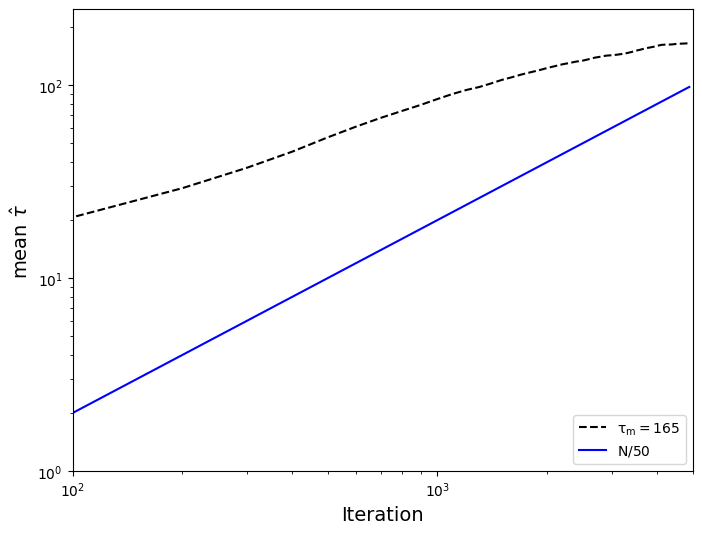

In [ ]:
# Autocorrelation time

f, ax = plt.subplots(1,1,figsize=(8,6))
ax.loglog(iteration, autocorr, ls='--', c='k',label=r'$\mathrm{\tau_m=}$'+str(round(taum,0)))
ax.loglog(iteration, n50, c='b',label=r'$\mathrm{N/50}$')
ax.set_xlim([100,niter])
ax.set_ylim([1, 1.5*np.nanmax(autocorr)])
ax.set_xlabel("Iteration",fontsize=14)
ax.set_ylabel(r"mean $\hat{\tau}$",fontsize=14)
plt.legend(loc=4)
plt.savefig(os.path.join(dir_inp,'tau.png'))


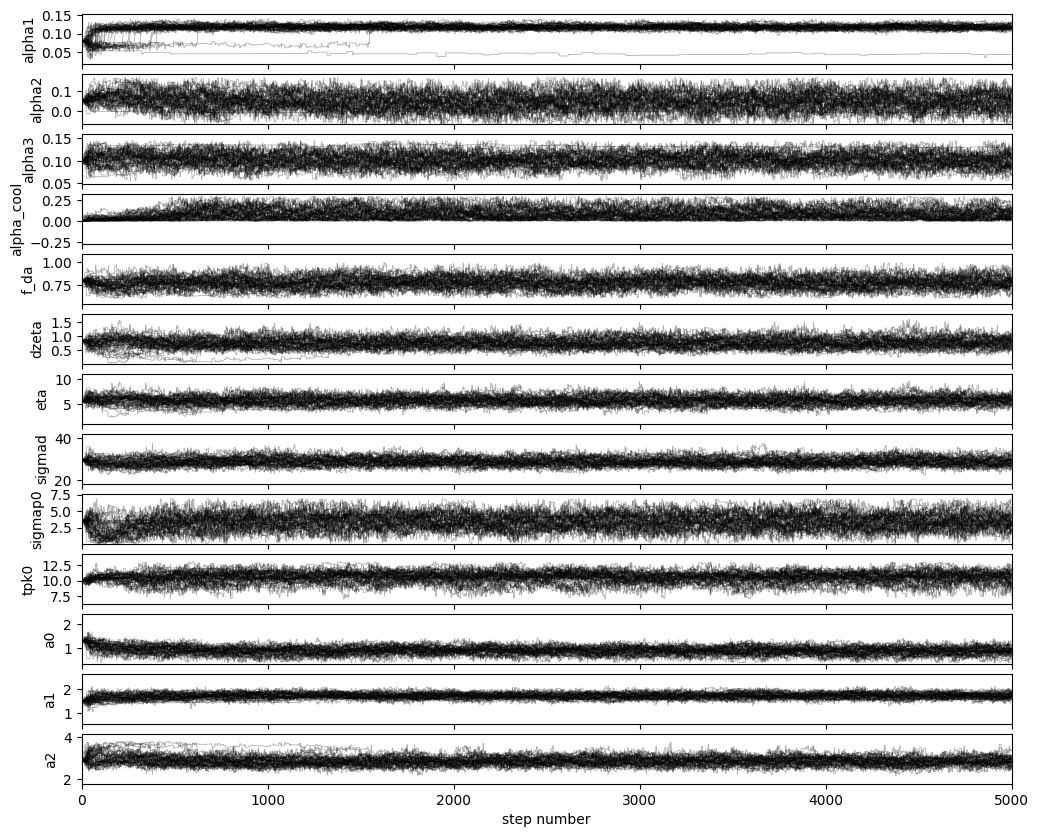

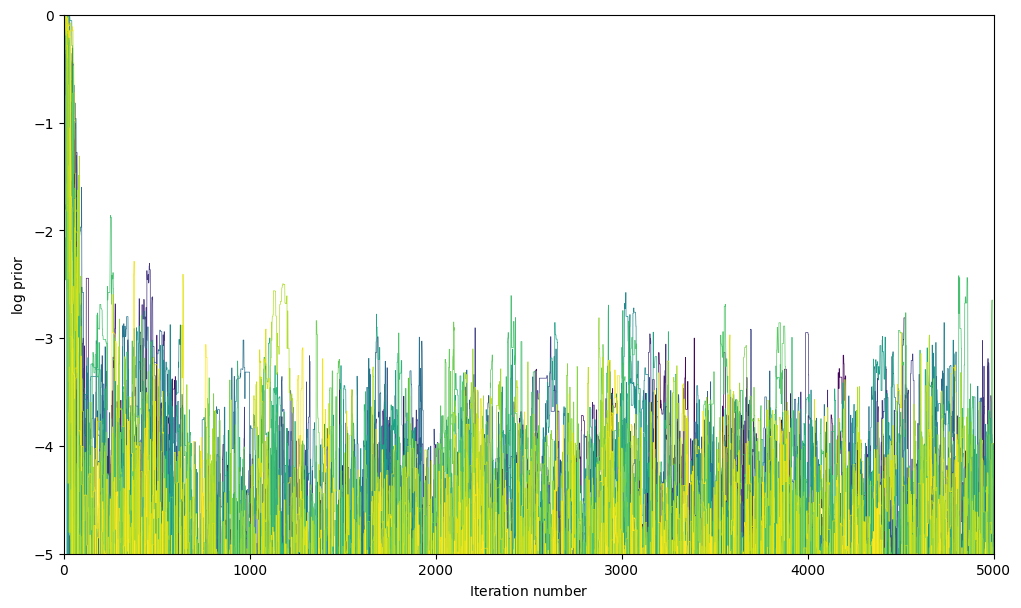

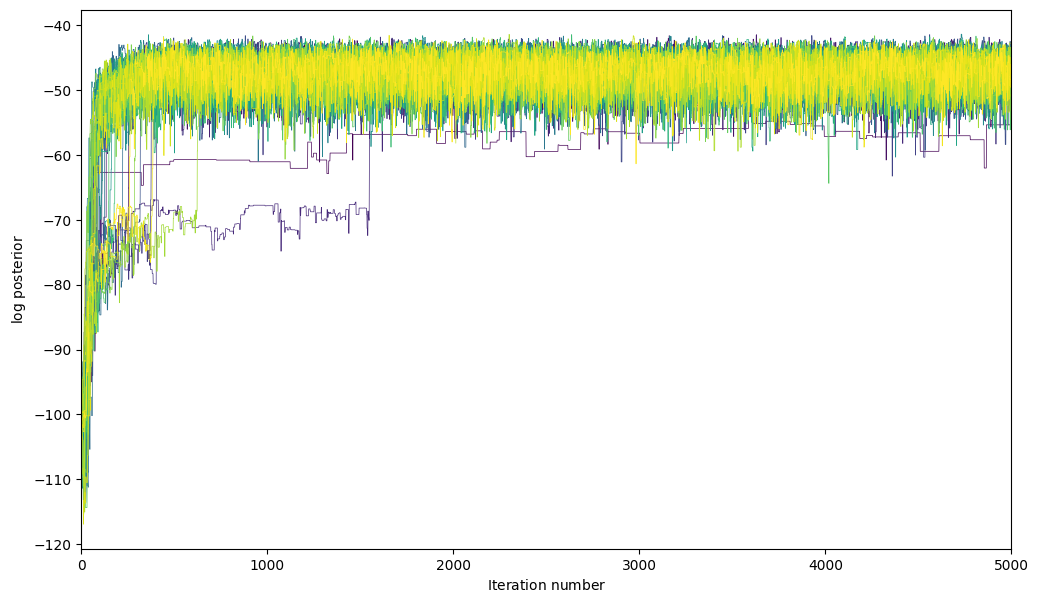

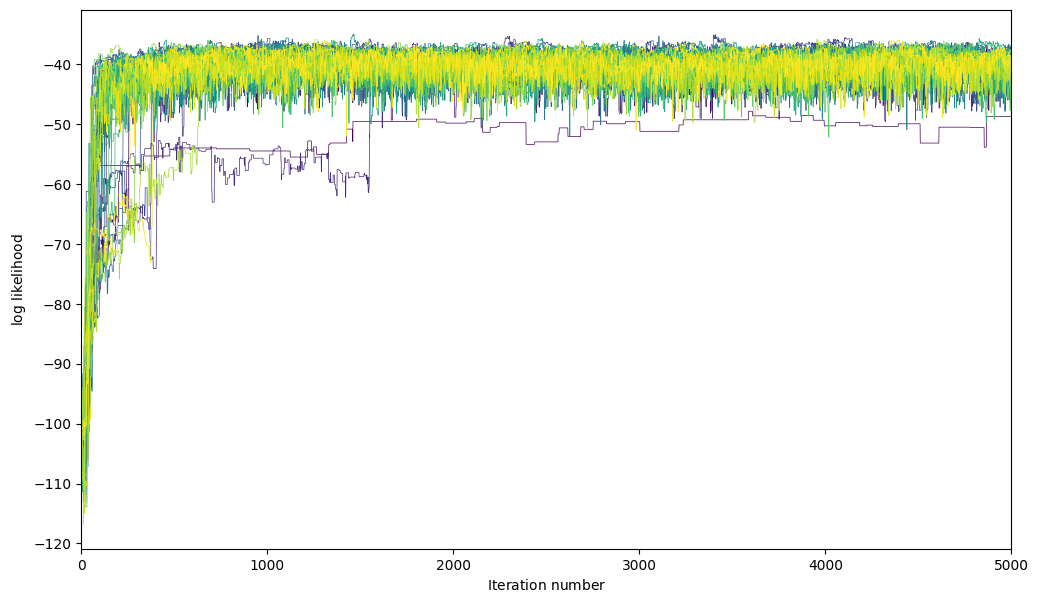

In [ ]:
# Plot all chains
# adapt y-range if needed

chain_cmap = mpl.colormaps['viridis']
chain_colors = chain_cmap(np.linspace(0,1,nwalkers))

ycoords = []
for i in range(ndim):
    ycoords.append((params_mean[i]-3*params_sigma[i],params_mean[i]+3*params_sigma[i]))


# All parameters in one plot
fig, axes = plt.subplots(ndim, figsize=(12, 10), sharex=True)
for i in range(ndim):
    ax = axes[i]
    for k in range(nwalkers):
        ax.plot(chains[:, k, i], lw=0.6, c='k', alpha=0.3)
    ax.set_xlim(0, len(chains))
    ax.set_ylabel(labels[i])
    ax.set_ylim(0.9*ycoords[i][0],1.1*ycoords[i][1])
axes[-1].set_xlabel("step number")
plt.savefig(os.path.join(dir_inp,'parameters.png'))

# Prior in chains
plt.figure(figsize=(12,7))
for k in range(nwalkers):
    plt.plot(log_prior[:,k],lw=0.5,c=chain_colors[k])
plt.ylabel(r'$\mathrm{log \ prior}$')
plt.xlabel(r'$\mathrm{Iteration \ number}$')
plt.xlim(0,niter)
plt.ylim(-5,0)
plt.savefig(os.path.join(dir_inp,'log_prior_chains.png'))

# Posterior in chains
plt.figure(figsize=(12,7))
for k in range(nwalkers):
    plt.plot(log_posterior[:,k],lw=0.5,c=chain_colors[k])
plt.ylabel(r'$\mathrm{log \ posterior}$')
plt.xlabel(r'$\mathrm{Iteration \ number}$')
plt.xlim(0,niter)
#plt.ylim(-8,0)
plt.savefig(os.path.join(dir_inp,'log_posterior_chains.png'))

plt.figure(figsize=(12,7))
for k in range(nwalkers):
    plt.plot(log_likelihood[:,k],lw=0.5,c=chain_colors[k])
plt.ylabel(r'$\mathrm{log \ likelihood}$')
plt.xlabel(r'$\mathrm{Iteration \ number}$')
plt.xlim(0,niter)
#plt.ylim(-5,-4)
plt.savefig(os.path.join(dir_inp,'log_likelihood_chains.png'))

# Each parameter separately, all iterations and after burn-in
for i in range(ndim):
    plt.figure(figsize=(12,7))
    for k in range(nwalkers):
        plt.plot(chains[:,k,i],lw=0.5,c=chain_colors[k])
    plt.ylabel(labels[i])
    plt.xlabel(r'$\mathrm{Iteration \ number}$')
    plt.axis([0,niter,0.9*ycoords[i][0],1.1*ycoords[i][1]])
    plt.savefig(os.path.join(dir_inp,''.join((labels[i],'_all.png'))))
    plt.close()

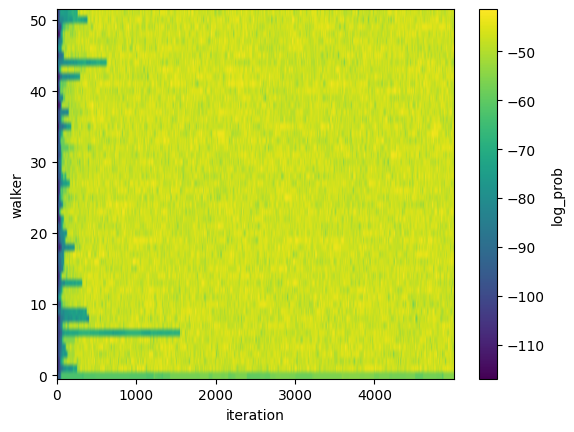

In [ ]:
# Another way of looking on chain mixing

plt.imshow(log_posterior.T, aspect='auto', origin='lower')
plt.colorbar(label='log_prob')
plt.xlabel('iteration'); plt.ylabel('walker')
plt.show()

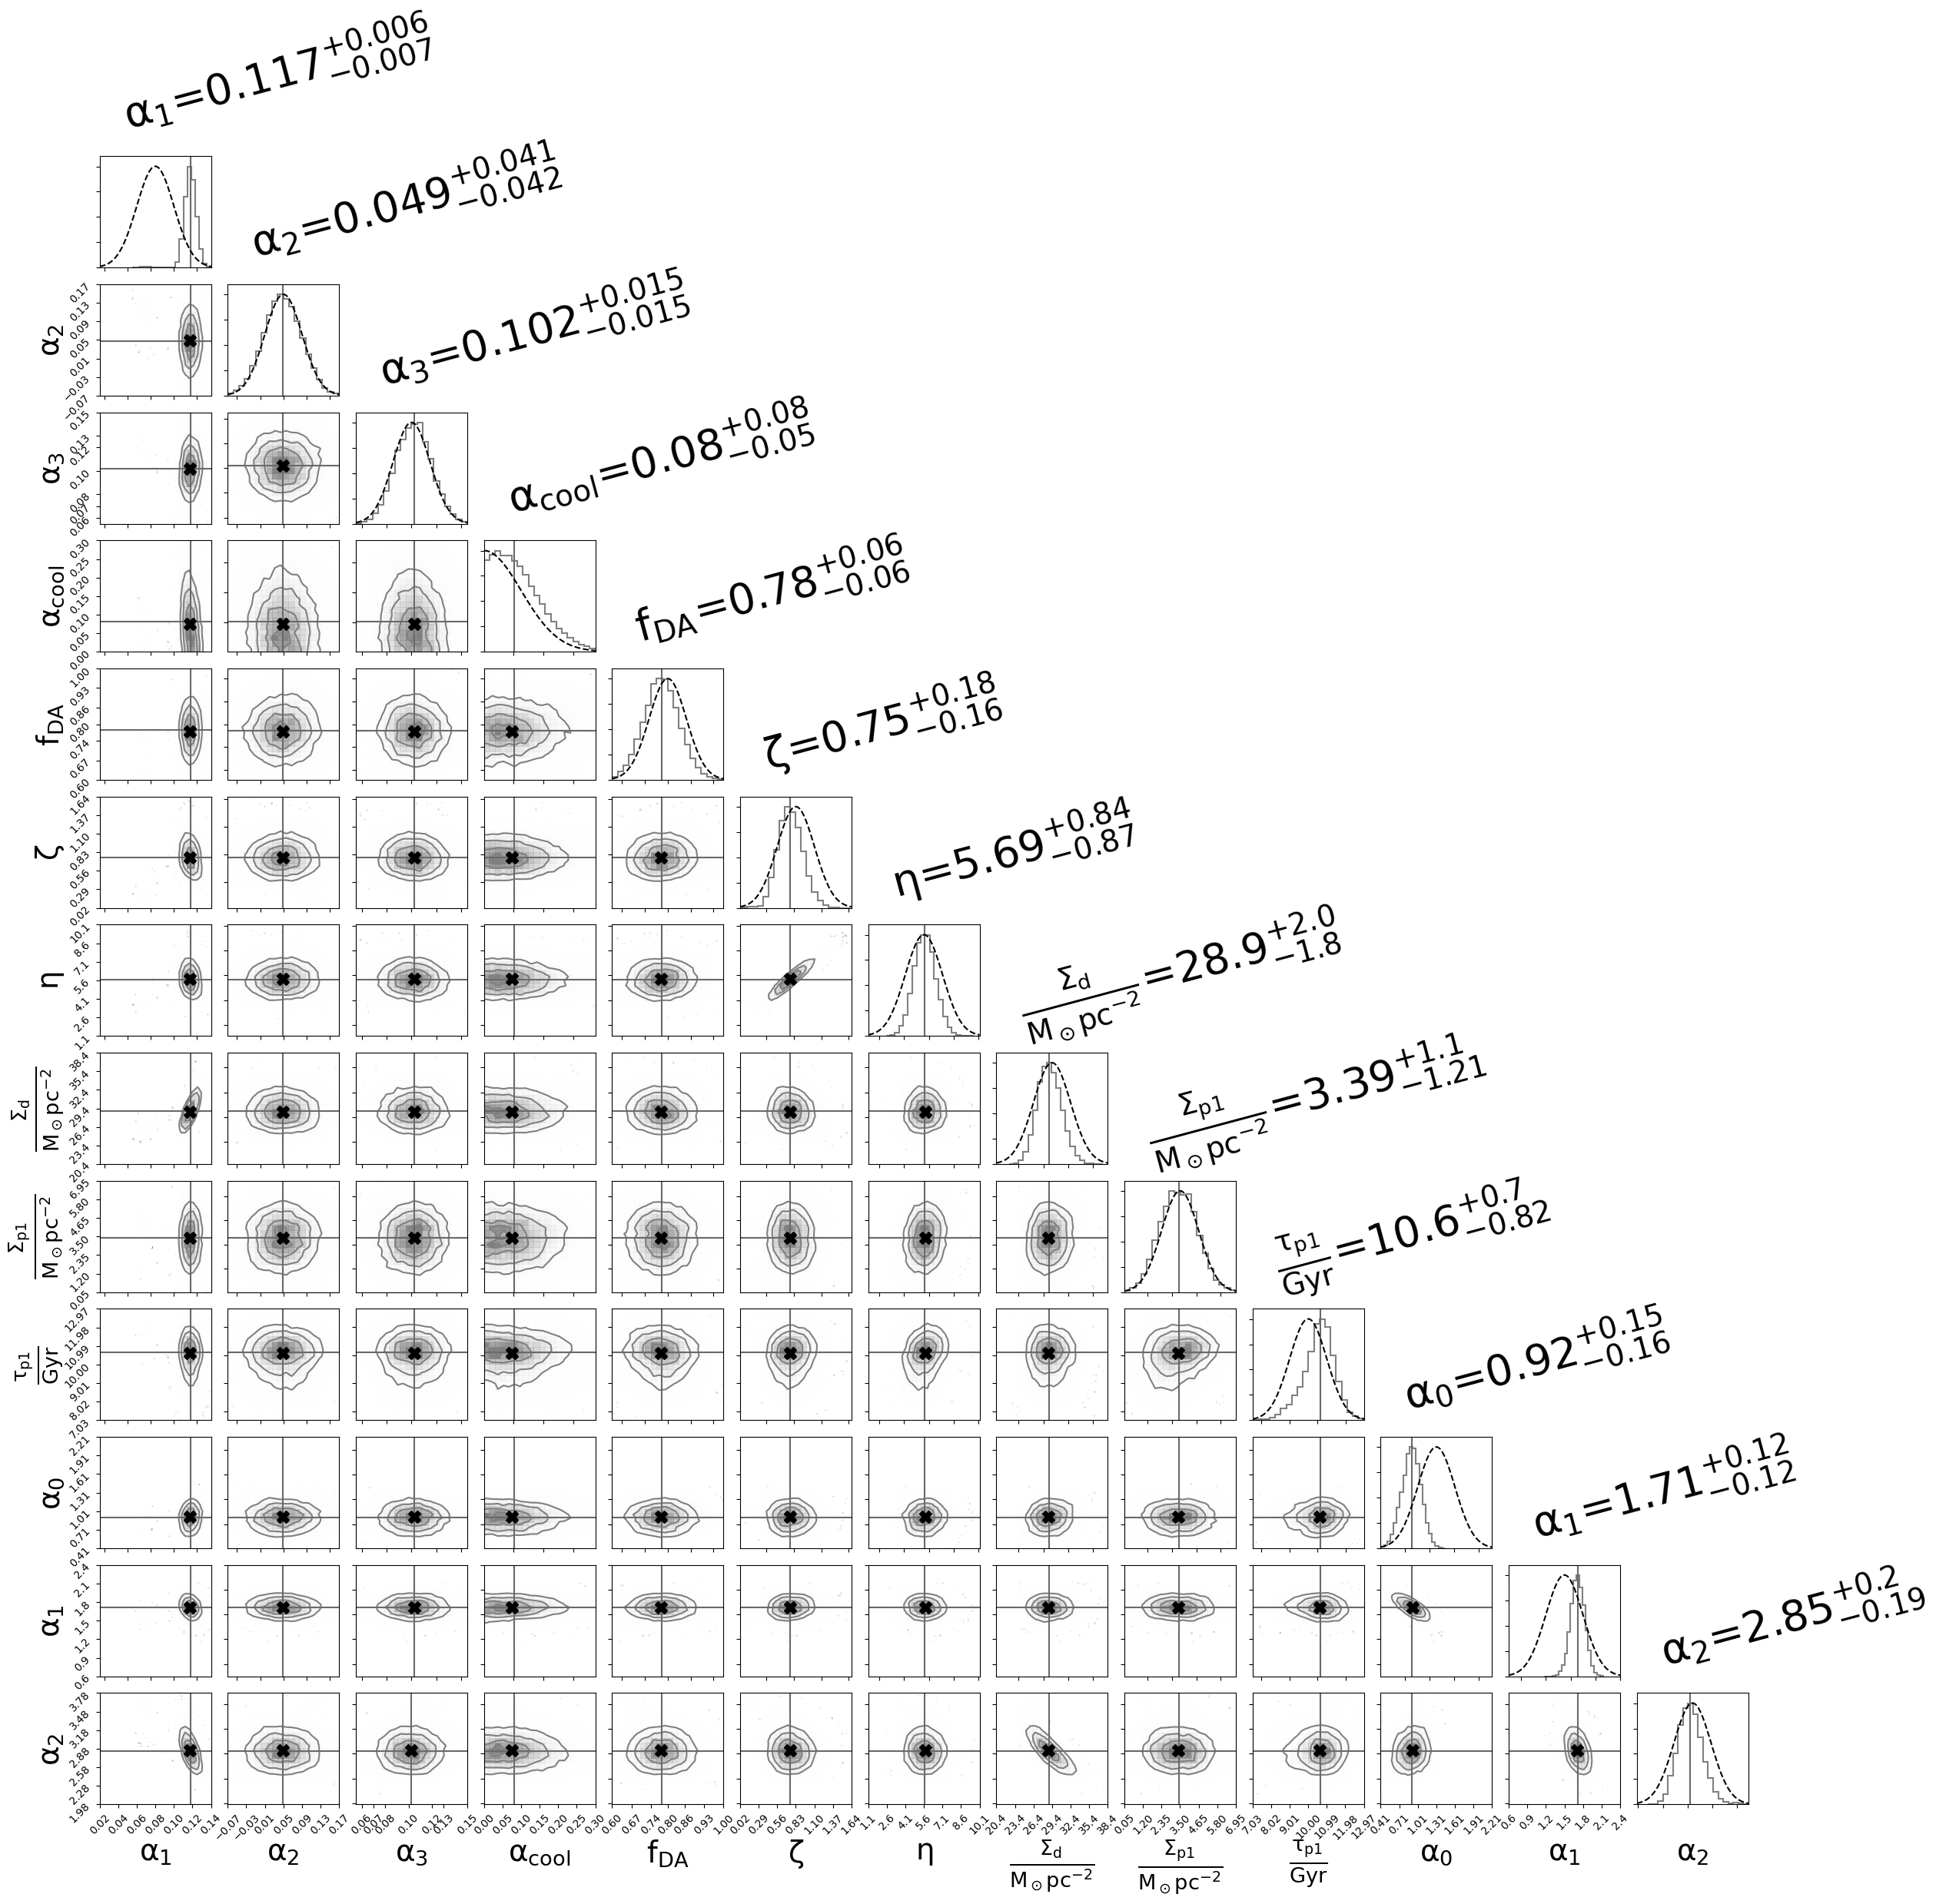

In [ ]:
# Corner plot, all iterations after burn-in

param_props = {
    'm_br1':{'l':r'$\mathrm{\frac{m_{br1}}{M_\odot}}$','r':2},
    'm_br2':{'l':r'$\mathrm{\frac{m_{br2}}{M_\odot}}$','r':2},
    'alpha1':{'l':r'$\mathrm{\alpha_1}$','r':3},
    'alpha2':{'l':r'$\mathrm{\alpha_2}$','r':3},
    'alpha3':{'l':r'$\mathrm{\alpha_3}$','r':3},
    'alpha_cool':{'l':r'$\mathrm{\alpha_{cool}}$','r':2},
    'f_da':{'l':r'$\mathrm{f_{DA}}$','r':2},
    'td2':{'l':r'$\mathrm{t_{d2}}$','r':2},
    'dzeta':{'l':r'$\mathrm{\zeta}$','r':2},
    'eta':{'l':r'$\mathrm{\eta}$','r':2},
    'sigmap0':{'l':r'$\mathrm{\frac{\Sigma_{p1}}{M_\odot pc^{-2}}}$','r':2},
    'sigmap1':{'l':r'$\mathrm{\frac{\Sigma_{p2}}{M_\odot pc^{-2}}}$','r':2},
    'sigmad':{'l':r'$\mathrm{\frac{\Sigma_{d}}{M_\odot pc^{-2}}}$','r':1},
    'tpk0':{'l':r'$\mathrm{\frac{\tau_{p1}}{Gyr}}$','r':2},
    'tpk1':{'l':r'$\mathrm{\frac{\tau_{p2}}{Gyr}}$','r':2},
    'tt1':{'l':r'$\mathrm{\frac{d\tau_{p1}}{Gyr}}$','r':2},
    'gamma':{'l':r'$\mathrm{\gamma}$','r':2},
    'beta':{'l':r'$\mathrm{\beta}$','r':2},
    'a0':{'l':r'$\mathrm{\alpha_{0}}$','r':2},
    'a1':{'l':r'$\mathrm{\alpha_{1}}$','r':2},
    'a2':{'l':r'$\mathrm{\alpha_{2}}$','r':2},
    'm0':{'l':r'$\mathrm{\frac{m_{0}}{M_\odot}}$','r':2},
    'm1':{'l':r'$\mathrm{\frac{m_{1}}{M_\odot}}$','r':2}    
}
labels = best_params[0]
p_names = [param_props[key]['l'] for key in labels]
nround = [param_props[key]['r'] for key in labels]

ranges = [] 
for i in range(ndim):
    if labels[i]=='alpha_cool':
        ranges.append((0,params_mean[i]+3*params_sigma[i]))
    else:
        ranges.append((params_mean[i]-3*params_sigma[i],
                       params_mean[i]+3*params_sigma[i]))
                   
# Full corner plot
hist2d_kwargs={'norm': mpl.colors.LogNorm(vmin=1e-5), 
               'vmin_factor': 5e-4, # adapts contrast
               'cmap': 'Greys_r'}

# I might need to exclude a stucked chain and recalculate best parameters
clean_chains = chains[:, 1:, :] # np.hstack((chains[:, :14, :],chains[:, 15:, :]))
clean_samples = get_sample(clean_chains,ind1, 1,flat=True)

best_values_corr, er1_corr, er2_corr = [],[],[]

for i in range(ndim):
    mcmc = np.percentile(clean_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    best_values_corr.append(round(mcmc[1],3))
    er1_corr.append(round(q[0],3))
    er2_corr.append(round(q[1],3))


#clean_samples = all_samples
fig = corner.corner(
    clean_samples, 
    labels=p_names,
    truths=best_values_corr,
    truth_color='dimgrey',
    smooth=0.2,
    label_kwargs={'fontsize':28},color='grey',
    hist_kwargs={'linewidth':1.5,'density':False},
    # contour_kwargs={'colors':'limegreen'}
    **hist2d_kwargs
    ); 

axes = np.array(fig.axes).reshape((ndim,ndim))
fig.subplots_adjust(bottom=0.1,left=0.1,top=0.85,right=0.85,wspace=0.15,hspace=0.15)
for i1 in range(ndim):
    for i2 in range(i1):
        ax = axes[i1,i2]
        ax.plot(best_values[i2],best_values[i1],marker='X',markersize=12,c='k')
        ax.set_ylim(ranges[i1][0],ranges[i1][1])
        ax.set_xlim(ranges[i2][0],ranges[i2][1])
          
        if i1 == ndim - 1:
            ax.xaxis.set_ticks(np.round(np.linspace(ranges[i2][0],ranges[i2][1],7),2))
        if i2 == 0:   
            ax.yaxis.set_ticks(np.round(np.linspace(ranges[i1][0],ranges[i1][1],7),2))
        if i2 != 0 and i1 != ndim - 1:
            ax.xaxis.set_ticklabels([])
            ax.yaxis.set_ticklabels([])  

    x = np.linspace(ranges[i1][0],ranges[i1][1],50)
    dx = x[1]-x[0]
    if i1==120 or i1==150:
        #mean = 13 - fitmode['parmean'][i1]
        #prior = np.exp(-(x-mean)**2/2/fitmode['parsigm'][i1]**2) 
        pass
    else:
        prior = np.exp(-(x-params_mean[i1])**2/2/params_sigma[i1]**2) 

    #axes[i1,i1].plot(x,prior/np.sum(prior*dx)*(30/50),c='k',ls='--')
    axes[i1,i1].plot(x,prior/np.max(prior),c='k',ls='--')
    axes[i1,i1].xaxis.set_ticklabels([])
    axes[i1,i1].set_xlim(ranges[i1][0],ranges[i1][1])
    axes[i1,i1].set_ylim(0,1.1)
    pos = axes[i1,i1].get_position()
    title = r"${{{0}}}_{{-{1}}}^{{+{2}}}$"
    label = p_names[i1] + '=' + title.format(round(best_values[i1],nround[i1]),
                                            round(err1[i1],nround[i1]),round(err2[i1],nround[i1]))
    fig.text(pos.x0+pos.width/4,pos.y0+1.25*pos.height,label,fontsize=40,rotation=15, rotation_mode='anchor')

fig.savefig(os.path.join(dir_inp,'posterior_all_samples.png'))


In [ ]:
# Print the best parameter values
np.array(best_values_corr)

array([ 0.117,  0.049,  0.102,  0.075,  0.775,  0.751,  5.693, 28.858,
        3.393, 10.602,  0.921,  1.708,  2.852])

In [2]:
# Check for stucked chains
# plt.plot(chains[:,2,1],lw=0.5)